Notebook to learn freesurfer pipeline functions

# 1. Tutorial data
[from here](https://surfer.nmr.mgh.harvard.edu/fswiki/FsTutorial/Data)

In [ ]:
# First, install required packages if you haven't already
# pip install nibabel numpy scipy

import nibabel as nib
from nibabel.freesurfer.io import read_geometry
import numpy as np
from scipy.ndimage import binary_fill_holes

def pial_to_volume(pial_file, output_shape=(256, 256, 256)):
    # Read the pial surface
    vertices, faces = read_geometry(pial_file)
    
    # Create an empty volume
    volume = np.zeros(output_shape, dtype=np.int16)
    
    # Convert vertices to voxel coordinates
    # You might need to adjust the scaling factor based on your needs
    vox_vertices = (vertices * (output_shape[0]/np.max(vertices))).astype(int)
    
    # Mark the surface points in the volume
    for vertex in vox_vertices:
        if np.all((vertex >= 0) & (vertex < output_shape)):
            volume[vertex[0], vertex[1], vertex[2]] = 1
    
    # Fill the holes to create a solid volume
    volume = binary_fill_holes(volume).astype(np.int16)
    
    # Create NIfTI image
    nifti_img = nib.Nifti1Image(volume, affine=np.eye(4))
    
    return nifti_img

# Usage example:

pial_file = "001/surf/lh.pial"
nifti_output = "lh.nii.gz"

# Convert pial to volume
volume_img = pial_to_volume(pial_file)

# Save as NIfTI
nib.save(volume_img, nifti_output)

In [47]:
# First, install required packages if you haven't already
# pip install nibabel numpy scipy

import nibabel as nib
from nibabel.freesurfer.io import read_geometry
import numpy as np
from scipy.ndimage import binary_fill_holes

def pial_to_volume(pial_file, output_shape=(256, 256, 256)):
    # Read the pial surface
    vertices, faces = read_geometry(pial_file)
    
    # Create an empty volume
    volume = np.zeros(output_shape, dtype=np.int16)
    
    # Convert vertices to voxel coordinates
    # You might need to adjust the scaling factor based on your needs
    vox_vertices = (vertices * (output_shape[0]/np.max(vertices))).astype(int)
    
    # Mark the surface points in the volume
    for vertex in vox_vertices:
        if np.all((vertex >= 0) & (vertex < output_shape)):
            volume[vertex[0], vertex[1], vertex[2]] = 1
    
    # Fill the holes to create a solid volume
    volume = binary_fill_holes(volume).astype(np.int16)
    
    # Create NIfTI image
    nifti_img = nib.Nifti1Image(volume, affine=np.eye(4))
    
    return nifti_img

# Usage example:
pial_file = "001/surf/rh.pial"
nifti_output = "rh.nii.gz"

# Convert pial to volume
volume_img = pial_to_volume(pial_file)

# Save as NIfTI
nib.save(volume_img, nifti_output)

In [49]:
# pip install trimesh
import trimesh
import numpy as np
import nibabel as nib

def pial_to_volume_trimesh(pial_file, resolution=1.0):
    # Read the surface as a mesh
    vertices, faces = read_geometry(pial_file)
    mesh = trimesh.Trimesh(vertices=vertices, faces=faces)
    
    # Voxelize the mesh
    voxels = mesh.voxelized(pitch=resolution)
    volume = voxels.matrix.astype(np.int16)
    
    # Create NIfTI image
    nifti_img = nib.Nifti1Image(volume, affine=np.eye(4))
    return nifti_img

nifti_out2 = pial_to_volume_trimesh("001/surf/lh.pial", resolution=1.0)
nifti_output2 = "lh.nii.gz"
# Convert pial to volume

# Save as NIfTI
nib.save(nifti_out2, nifti_output2)

nifti_out3 = pial_to_volume_trimesh("001/surf/rh.pial", resolution=1.0)
nifti_output3 = "rh.nii.gz"
nib.save(nifti_out3, nifti_output3)

In [2]:
from pycad.converters import NiftiToNrrdConverter

# Initialize converter
converter = NiftiToNrrdConverter()

input_path = "output_volume.nii.gz"
output_dir = "."

# Perform the conversion
converter.convert(input_path, output_dir)

2024-11-25 11:21:59,082 - NiftiToNrrdConverter - INFO - Converted output_volume.nii.gz to ./output_volume.nrrd
2024-11-25 11:21:59,082 - NiftiToNrrdConverter - INFO - Converted output_volume.nii.gz to ./output_volume.nrrd


In [3]:
import numpy as np
import nibabel as nib
from skimage import measure

# Load NIfTI file
input_path = "output_volume.nii.gz"
image = nib.load(input_path)
image_data = image.get_fdata()

# Extract surface mesh using marching cubes
verts, faces, normals, values = measure.marching_cubes(image_data, level=0)

# verts and faces can now be used to create a mesh in your visualization tool

array([[     2,      1,      0],
       [     4,      3,      0],
       [     0,      3,      2],
       ...,
       [232412, 234454, 232387],
       [234455, 232416, 232390],
       [232416, 234455, 232393]], dtype=int32)

In [12]:
import nibabel as nib
import numpy as np

input_path = "001/mri/left_thalamus.nii.gz"
image = nib.load(input_path)
image_data = image.get_fdata()
image_data.shape

(256, 256, 256)

In [17]:
z,x,y = image_data.nonzero()

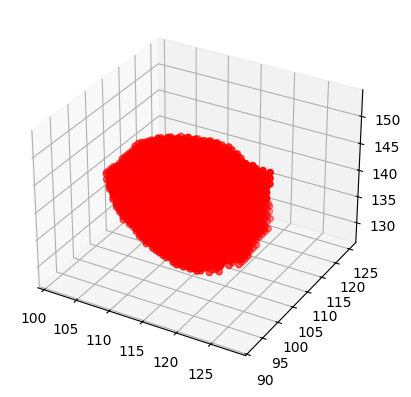

In [27]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
# ax.set_xlim(0, 256)
# ax.set_ylim(0, 256)
# ax.set_zlim(0, 256)
ax.scatter(x, y, z, zdir='z', c= 'red')

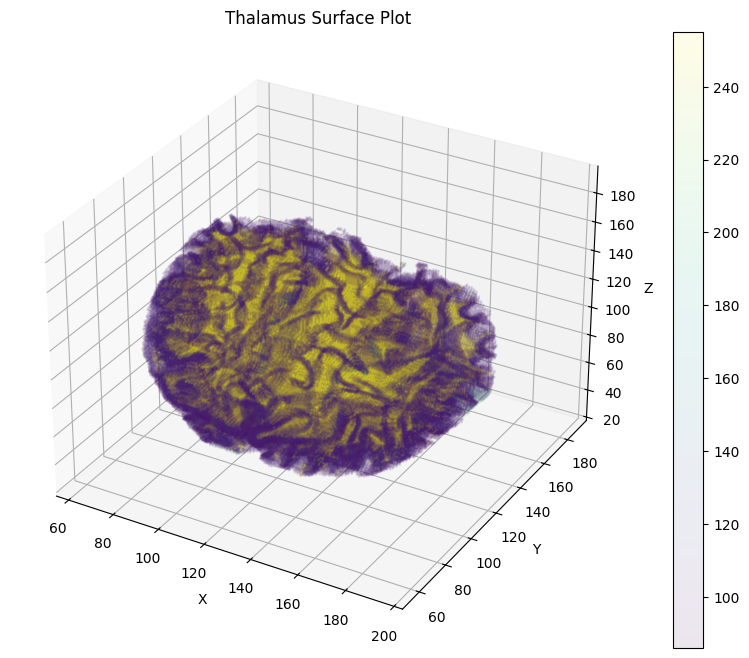

In [36]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import nibabel as nib

# Load the data
input_path = "001/mri/wm.nii.gz"
image = nib.load(input_path)
image_data = image.get_fdata()

# Create a figure
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Create coordinates for non-zero voxels
x, y, z = np.where(image_data > 0)  # Get coordinates of non-zero voxels

# Plot the surface
scatter = ax.scatter(x, y, z, c=image_data[x, y, z], 
                    cmap='viridis', 
                    alpha=0.1,  # Make points semi-transparent
                    s=1)  # Small point size

# Add a colorbar
plt.colorbar(scatter)

# Set labels
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title('Thalamus Surface Plot')

# Adjust the view
# ax.view_init(elev=20, azim=45)
ax.mouse_init()

plt.show()

Nifti to obj

In [41]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from skimage import measure
import nibabel as nib
from scipy.ndimage import zoom

# nifti to py
input_path = "001/mri/wm.nii.gz"
image = nib.load(input_path)
image_data = image.get_fdata()


scale_factor = 1  # This will reduce the size to x% in each dimension
downsampled_data = zoom(image_data, scale_factor)

# isosurface
verts, faces, normals, values = measure.marching_cubes(downsampled_data, level=0.5, step_size=5)

# Save as OBJ file (3D format)
def save_obj(vertices, faces, filename):
    with open(filename, 'w') as f:
        for v in vertices:
            f.write(f'v {v[0]} {v[1]} {v[2]}\n')
        for face in faces:
            f.write(f'f {face[0]+1} {face[1]+1} {face[2]+1}\n')

save_obj(verts, faces, 'wm_step5.obj')

# Optional: Save as PLY format (another common 3D format)
# from skimage.io import imsave
# from sklearn.preprocessing import MinMaxScaler

# def save_ply(vertices, faces, filename):
#     with open(filename, 'w') as f:
#         # Write header
#         f.write("ply\n")
#         f.write("format ascii 1.0\n")
#         f.write(f"element vertex {len(vertices)}\n")
#         f.write("property float x\n")
#         f.write("property float y\n")
#         f.write("property float z\n")
#         f.write(f"element face {len(faces)}\n")
#         f.write("property list uchar int vertex_indices\n")
#         f.write("end_header\n")
        
#         # Write vertices
#         for v in vertices:
#             f.write(f"{v[0]} {v[1]} {v[2]}\n")
        
#         # Write faces
#         for face in faces:
#             f.write(f"3 {face[0]} {face[1]} {face[2]}\n")

# save_ply(verts, faces, 'thalamus.ply')

Higher quality ? 

In [44]:
import numpy as np
import nibabel as nib
from skimage import measure
from scipy import ndimage
from scipy.spatial import Delaunay

def refine_mesh(vertices, faces):
    # Create new vertices at face centers
    face_centers = vertices[faces].mean(axis=1)
    new_vertices = np.vstack([vertices, face_centers])
    
    # Triangulate the new point set
    tri = Delaunay(new_vertices)
    return new_vertices, tri.simplices

# Load the data
input_path = "001/mri/wm.nii.gz"
image = nib.load(input_path)
image_data = image.get_fdata()

# Optional: Apply slight smoothing to reduce noise while keeping detail
smooth_data = ndimage.gaussian_filter(image_data, sigma=0.3)

# Generate high-quality isosurface
# Using small step_size for maximum detail
verts, faces, normals, values = measure.marching_cubes(
    smooth_data, 
    level=0.2,
    step_size=1,  # smallest step size for maximum detail
    allow_degenerate=False,
    method='lewiner'  # this method generally gives better quality
)

refined_verts, refined_faces = refine_mesh(verts, faces)

print(f"Number of vertices: {len(verts)}")
print(f"Number of faces: {len(faces)}")

# Save as PLY with normals (higher quality)
def save_detailed_ply(vertices, faces, normals, filename):
    with open(filename, 'w') as f:
        # Write header
        f.write("ply\n")
        f.write("format ascii 1.0\n")
        f.write(f"element vertex {len(vertices)}\n")
        f.write("property float x\n")
        f.write("property float y\n")
        f.write("property float z\n")
        f.write("property float nx\n")
        f.write("property float ny\n")
        f.write("property float nz\n")
        f.write(f"element face {len(faces)}\n")
        f.write("property list uchar int vertex_indices\n")
        f.write("end_header\n")
        
        # Write vertices with normals
        for v, n in zip(vertices, normals):
            f.write(f"{v[0]} {v[1]} {v[2]} {n[0]} {n[1]} {n[2]}\n")
        
        # Write faces
        for face in faces:
            f.write(f"3 {face[0]} {face[1]} {face[2]}\n")

# Save as OBJ with normals
def save_detailed_obj(vertices, faces, normals, filename):
    with open(filename, 'w') as f:
        # Write vertices
        for v in vertices:
            f.write(f"v {v[0]} {v[1]} {v[2]}\n")
        
        # Write vertex normals
        for n in normals:
            f.write(f"vn {n[0]} {n[1]} {n[2]}\n")
        
        # Write faces with normal indices
        for idx, face in enumerate(faces):
            f.write(f"f {face[0]+1}//{face[0]+1} {face[1]+1}//{face[1]+1} {face[2]+1}//{face[2]+1}\n")

# Save both formats
save_detailed_ply(verts, faces, normals, 'wm3.ply')
save_detailed_obj(verts, faces, normals, 'wm3.obj')

# Optional: If you want to verify the mesh quality
from sklearn.preprocessing import MinMaxScaler

# Calculate some mesh statistics
edge_lengths = []
for face in faces:
    for i in range(3):
        v1 = verts[face[i]]
        v2 = verts[face[(i+1)%3]]
        edge_lengths.append(np.sqrt(np.sum((v1-v2)**2)))

print(f"\nMesh Statistics:")
print(f"Average edge length: {np.mean(edge_lengths):.4f}")
print(f"Min edge length: {np.min(edge_lengths):.4f}")
print(f"Max edge length: {np.max(edge_lengths):.4f}")

Number of vertices: 259751
Number of faces: 519846

Mesh Statistics:
Average edge length: 0.9676
Min edge length: 0.0680
Max edge length: 1.6452


Todo : compare with nii2mesh

In [2]:
import nibabel as nib
import numpy as np

# Load the NIfTI file
file_path = '/Users/arnaud/Downloads/V1.0/sub-116056/ses-3mo/anat/sub-116056_ses-3mo_space-INFANTMNIacpc_desc-aseg_dseg.nii.gz'  # Replace with your file path
nifti_img = nib.load(file_path)

# Get the data as a NumPy array
segmentation_data = nifti_img.get_fdata()

# Print some details about the data
print("Data shape:", segmentation_data.shape)
print("Data type:", segmentation_data.dtype)

# Inspect unique segmentation labels
unique_labels = np.unique(segmentation_data)
print("Unique segmentation labels:", unique_labels)


Data shape: (182, 218, 182)
Data type: float64
Unique segmentation labels: [  0.   2.   3.   4.   5.   7.   8.  10.  11.  12.  13.  14.  15.  16.
  17.  18.  26.  28.  31.  41.  42.  43.  44.  46.  47.  49.  50.  51.
  52.  53.  54.  58.  60.  63. 172.]
